<a href="https://colab.research.google.com/github/AhmedButtar7/ML_Assignment/blob/main/KAN_based_research_code_for_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os

DRIVE_ROOT = '/content/drive/MyDrive/KAN_Stability_Study'
PATHS = {
    'root': DRIVE_ROOT,
    'data': os.path.join(DRIVE_ROOT, 'data'),
    'results': os.path.join(DRIVE_ROOT, 'results'),
    'figures': os.path.join(DRIVE_ROOT, 'figures'),
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

print("Drive mounted at:", DRIVE_ROOT)

Drive mounted at: /content/drive/MyDrive/KAN_Stability_Study


In [ ]:
# Set this to a different value on each Colab account:
#   Account 1 -> 'bspline'
#   Account 2 -> 'chebyshev_raw'
#   Account 3 -> 'chebyshev_tanh'
#   Account 4 (or whichever finishes first) -> 'mlp'
APPROACH = 'mlp'

assert APPROACH in ('bspline', 'chebyshev_raw', 'chebyshev_tanh', 'mlp')
print(f"This notebook will run ALL experiments for approach: {APPROACH}")

This notebook will run ALL experiments for approach: mlp


In [ ]:
import time, random, math, glob
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cuda


In [ ]:
SEEDS = [42, 123, 456, 789, 1011, 2024, 3030, 4040, 5050, 6060]
GRID_SIZES = [3, 5]
PRIMARY_EPOCHS = 50
PRIMARY_LR = 1e-3
BATCH_SIZE = 128
VAL_FRACTION = 0.1
DATA_SPLIT_SEED = 0  # fixed across all accounts so splits match exactly

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

In [ ]:
def get_mnist_loaders(batch_size=BATCH_SIZE):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1) * 2 - 1),
    ])
    train_full = torchvision.datasets.MNIST(root=PATHS['data'], train=True, download=True, transform=transform)
    test_set = torchvision.datasets.MNIST(root=PATHS['data'], train=False, download=True, transform=transform)

    n_val = int(len(train_full) * VAL_FRACTION)
    n_train = len(train_full) - n_val
    gen = torch.Generator().manual_seed(DATA_SPLIT_SEED)
    train_set, val_set = random_split(train_full, [n_train, n_val], generator=gen)

    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_set, val_loader, test_loader

def make_train_loader(train_set, seed, batch_size=BATCH_SIZE):
    g = torch.Generator(); g.manual_seed(seed)
    return DataLoader(train_set, batch_size=batch_size, shuffle=True, generator=g, num_workers=2)

def get_synthetic_function_data(n_samples=2000, seed=0):
    rng = np.random.RandomState(seed)
    x = rng.uniform(-1, 1, size=(n_samples, 1)).astype(np.float32)
    with np.errstate(divide='ignore', invalid='ignore'):
        y = np.sin(20 * x) / (20 * x)
    y = np.nan_to_num(y, nan=1.0).astype(np.float32)
    ds = TensorDataset(torch.tensor(x), torch.tensor(y))
    n_val = int(0.2 * n_samples); n_train = n_samples - n_val
    gen = torch.Generator().manual_seed(DATA_SPLIT_SEED)
    return random_split(ds, [n_train, n_val], generator=gen)

def get_concrete_dataset():
    local_path = os.path.join(PATHS['data'], 'concrete_data.xls')
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    if not os.path.exists(local_path):
        import urllib.request
        urllib.request.urlretrieve(url, local_path)
    df = pd.read_excel(local_path)
    X = df.iloc[:, :-1].values.astype(np.float32)
    y = df.iloc[:, -1].values.astype(np.float32).reshape(-1, 1)
    X = (X - X.mean(0)) / (X.std(0) + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    n_val = int(0.2 * len(ds)); n_train = len(ds) - n_val
    gen = torch.Generator().manual_seed(DATA_SPLIT_SEED)
    return random_split(ds, [n_train, n_val], generator=gen), X.shape[1]

In [ ]:
class KANLinearBSpline(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 scale_noise=0.1, scale_base=1.0, scale_spline=1.0, grid_range=(-1, 1)):
        super().__init__()
        self.in_features, self.out_features = in_features, out_features
        self.grid_size, self.spline_order = grid_size, spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0])
        grid = grid.expand(in_features, -1).contiguous()
        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(torch.empty(out_features, in_features, grid_size + spline_order))
        self.base_activation = nn.SiLU()
        self.scale_noise, self.scale_base, self.scale_spline = scale_noise, scale_base, scale_spline
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
            noise = noise * self.scale_noise / self.grid_size
            x_sample = self.grid.T[self.spline_order:-self.spline_order]
            coeff = self.curve2coeff(x_sample, noise)
            self.spline_weight.data.copy_(self.scale_spline * coeff)

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            left = (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)] + 1e-12) * bases[:, :, :-1]
            right = (grid[:, k + 1:] - x) / (grid[:, k + 1:] - grid[:, 1:-k] + 1e-12) * bases[:, :, 1:]
            bases = left + right
        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    def forward(self, x):
        base_out = F.linear(self.base_activation(x), self.base_weight)
        spline_out = F.linear(self.b_splines(x).view(x.size(0), -1), self.spline_weight.view(self.out_features, -1))
        return base_out + spline_out

In [ ]:
class ChebyKANLayer(nn.Module):
    def __init__(self, in_features, out_features, degree, stabilize=False):
        super().__init__()
        self.in_features, self.out_features = in_features, out_features
        self.degree, self.stabilize = degree, stabilize
        self.coeffs = nn.Parameter(torch.empty(in_features, out_features, degree + 1))
        nn.init.normal_(self.coeffs, mean=0.0, std=1.0 / math.sqrt(in_features * (degree + 1)))

    def forward(self, x):
        if self.stabilize:
            x = torch.tanh(x)
        Ts = [torch.ones_like(x), x]
        for _ in range(2, self.degree + 1):
            Ts.append(2 * x * Ts[-1] - Ts[-2])
        T = torch.stack(Ts, dim=-1)
        return torch.einsum('bid,iod->bo', T, self.coeffs)

In [ ]:
class KANNetwork(nn.Module):
    def __init__(self, layer_sizes, basis, grid_size=5, degree=5, stabilize=False):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layer_sizes) - 1):
            if basis == 'bspline':
                self.layers.append(KANLinearBSpline(layer_sizes[i], layer_sizes[i + 1], grid_size=grid_size))
            elif basis == 'chebyshev':
                self.layers.append(ChebyKANLayer(layer_sizes[i], layer_sizes[i + 1], degree=degree, stabilize=stabilize))
            else:
                raise ValueError(basis)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

def build_matched_mlp(target_params, in_dim=784, out_dim=10, max_iter=60):
    lo, hi = 1, 8000
    best_h, best_diff = 1, float('inf')
    for _ in range(max_iter):
        if lo > hi: break
        h = (lo + hi) // 2
        p = (in_dim * h + h) + (h * out_dim + out_dim)
        diff = abs(p - target_params) / target_params
        if diff < best_diff: best_diff, best_h = diff, h
        if p < target_params: lo = h + 1
        else: hi = h - 1
    return best_h

def build_model(config):
    if config['model_type'] == 'mlp':
        return nn.Sequential(
            nn.Linear(config['in_dim'], config['mlp_hidden']),
            nn.ReLU(),
            nn.Linear(config['mlp_hidden'], config['out_dim']),
        ).to(DEVICE)
    return KANNetwork(
        config['layer_sizes'], basis=config['basis'],
        grid_size=config.get('grid_size', 5), degree=config.get('degree', 5),
        stabilize=config.get('stabilize', False),
    ).to(DEVICE)

In [ ]:
def append_result(result, csv_path):
    df_row = pd.DataFrame([result])
    if os.path.exists(csv_path):
        df_row.to_csv(csv_path, mode='a', header=False, index=False)
    else:
        df_row.to_csv(csv_path, mode='w', header=True, index=False)

def load_completed_run_ids(csv_path):
    if not os.path.exists(csv_path):
        return set()
    try:
        return set(pd.read_csv(csv_path)['run_id'].astype(str).tolist())
    except Exception:
        return set()

In [ ]:
def train_one_run(config, train_loader_fn, val_loader, test_loader=None, task='classification'):
    set_seed(config['seed'])
    model = build_model(config)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get('lr', 1e-3))
    criterion = nn.CrossEntropyLoss() if task == 'classification' else nn.MSELoss()
    train_loader = train_loader_fn(config['seed'])

    epochs = config.get('epochs', 50)
    val_losses, val_accs = [], []
    epoch_to_90, epoch_to_95 = None, None
    failed, fail_reason = False, None

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            if torch.isnan(loss) or torch.isinf(loss):
                failed, fail_reason = True, 'nan_inf_train_loss'; break
            loss.backward()
            bad_grad = any(p.grad is not None and (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
                           for p in model.parameters())
            if bad_grad:
                failed, fail_reason = True, 'nan_inf_gradient'; break
            optimizer.step()
        if failed: break

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss = criterion(out, yb)
                if torch.isnan(loss) or torch.isinf(loss):
                    failed, fail_reason = True, 'nan_inf_val_loss'; break
                total_loss += loss.item() * xb.size(0)
                if task == 'classification':
                    correct += (out.argmax(1) == yb).sum().item()
                total += xb.size(0)
        if failed: break

        val_loss = total_loss / total
        val_losses.append(val_loss)
        if task == 'classification':
            val_acc = correct / total
            val_accs.append(val_acc)
            if epoch_to_90 is None and val_acc >= 0.90: epoch_to_90 = epoch + 1
            if epoch_to_95 is None and val_acc >= 0.95: epoch_to_95 = epoch + 1

    train_time = time.time() - t0
    peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else float('nan')
    n_params = count_params(model)

    test_metric = None
    if not failed and test_loader is not None:
        model.eval()
        if task == 'classification':
            correct, total = 0, 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    out = model(xb)
                    correct += (out.argmax(1) == yb).sum().item(); total += xb.size(0)
            test_metric = correct / total
        else:
            se, n = 0.0, 0
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    out = model(xb)
                    se += F.mse_loss(out, yb, reduction='sum').item(); n += xb.numel()
            test_metric = se / n

    result = {k: v for k, v in config.items() if k != 'layer_sizes'}
    result['layer_sizes'] = str(config.get('layer_sizes'))
    result.update({
        'failed': failed, 'fail_reason': fail_reason,
        'final_val_loss': val_losses[-1] if val_losses else float('nan'),
        'final_val_acc': val_accs[-1] if val_accs else float('nan'),
        'peak_val_acc': max(val_accs) if val_accs else float('nan'),
        'val_loss_std_lastk': float(np.std(val_losses[-5:])) if len(val_losses) >= 2 else float('nan'),
        'epoch_to_90': epoch_to_90, 'epoch_to_95': epoch_to_95,
        'n_params': n_params, 'train_time_sec': train_time, 'peak_gpu_mem_mb': peak_mem,
        'test_metric': test_metric, 'n_epochs_completed': len(val_losses),
    })
    return result

In [ ]:
train_set, val_loader, test_loader = get_mnist_loaders()
make_train_loader_fn = lambda seed: make_train_loader(train_set, seed)

ref_kan = KANNetwork([784, 64, 10], basis='bspline', grid_size=5)
ref_params = count_params(ref_kan)
MLP_HIDDEN = build_matched_mlp(ref_params, in_dim=784, out_dim=10)
print(f"Reference KAN params: {ref_params} -> matched MLP hidden size: {MLP_HIDDEN}")

Reference KAN params: 457344 -> matched MLP hidden size: 575


In [ ]:
APPROACH_SPECS = {
    'bspline': {'basis': 'bspline', 'stabilize': False},
    'chebyshev_raw': {'basis': 'chebyshev', 'stabilize': False},
    'chebyshev_tanh': {'basis': 'chebyshev', 'stabilize': True},
}

PRIMARY_CSV = os.path.join(PATHS['results'], f'primary_results__{APPROACH}.csv')
completed = load_completed_run_ids(PRIMARY_CSV)

if APPROACH == 'mlp':
    configs = [{
        'run_id': f"mlp_seed{seed}", 'model_type': 'mlp', 'config_name': 'mlp_baseline',
        'in_dim': 784, 'out_dim': 10, 'mlp_hidden': MLP_HIDDEN,
        'seed': seed, 'lr': PRIMARY_LR, 'epochs': PRIMARY_EPOCHS, 'experiment': 'primary',
    } for seed in SEEDS]
else:
    spec = APPROACH_SPECS[APPROACH]
    configs = [{
        'run_id': f"{APPROACH}_grid{grid}_seed{seed}", 'model_type': 'kan', 'config_name': APPROACH,
        'basis': spec['basis'], 'stabilize': spec['stabilize'],
        'grid_size': grid, 'degree': grid, 'layer_sizes': [784, 64, 10],
        'seed': seed, 'lr': PRIMARY_LR, 'epochs': PRIMARY_EPOCHS, 'experiment': 'primary',
    } for grid in GRID_SIZES for seed in SEEDS]

print(f"[{APPROACH}] primary: {len(configs)} runs, {len(completed)} already done")
for i, cfg in enumerate(configs):
    if cfg['run_id'] in completed:
        continue
    print(f"[{i+1}/{len(configs)}] {cfg['run_id']} ...")
    result = train_one_run(cfg, make_train_loader_fn, val_loader, test_loader, task='classification')
    append_result(result, PRIMARY_CSV)
    print(f"  -> failed={result['failed']} val_acc={result['final_val_acc']:.4f} time={result['train_time_sec']:.1f}s")

print(f"[{APPROACH}] primary experiment done.")

NameError: name 'APPROACH' is not defined

In [ ]:
if APPROACH == 'mlp':
    print("LR sensitivity is only run for the KAN variants — skipping on this account.")
else:
    LR_VALUES = [1e-4, 5e-4, 1e-3]
    LR_SEEDS = SEEDS[:5]
    spec = APPROACH_SPECS[APPROACH]
    LR_CSV = os.path.join(PATHS['results'], f'lr_sensitivity_results__{APPROACH}.csv')
    completed = load_completed_run_ids(LR_CSV)

    configs = [{
        'run_id': f"lr_{APPROACH}_lr{lr}_seed{seed}", 'model_type': 'kan', 'config_name': APPROACH,
        'basis': spec['basis'], 'stabilize': spec['stabilize'],
        'grid_size': 5, 'degree': 5, 'layer_sizes': [784, 64, 10],
        'seed': seed, 'lr': lr, 'epochs': PRIMARY_EPOCHS, 'experiment': 'lr_sensitivity',
    } for lr in LR_VALUES for seed in LR_SEEDS]

    print(f"[{APPROACH}] lr sensitivity: {len(configs)} runs, {len(completed)} already done")
    for i, cfg in enumerate(configs):
        if cfg['run_id'] in completed:
            continue
        print(f"[{i+1}/{len(configs)}] {cfg['run_id']} ...")
        result = train_one_run(cfg, make_train_loader_fn, val_loader, test_loader, task='classification')
        append_result(result, LR_CSV)

    print(f"[{APPROACH}] lr sensitivity done.")

LR sensitivity is only run for the KAN variants — skipping on this account.


In [ ]:
if APPROACH != 'chebyshev_raw':
    print("Depth ablation is only run for raw Chebyshev — skipping on this account.")
else:
    DEPTH_ARCHS = {2: [784, 64, 10], 3: [784, 64, 64, 10], 4: [784, 64, 64, 64, 10]}
    DEPTH_SEEDS = SEEDS[:5]
    DEPTH_CSV = os.path.join(PATHS['results'], f'depth_ablation_results__{APPROACH}.csv')
    completed = load_completed_run_ids(DEPTH_CSV)

    configs = [{
        'run_id': f"depth{depth}_{APPROACH}_seed{seed}", 'model_type': 'kan', 'config_name': APPROACH,
        'basis': 'chebyshev', 'stabilize': False, 'degree': 5, 'layer_sizes': arch, 'depth': depth,
        'seed': seed, 'lr': PRIMARY_LR, 'epochs': PRIMARY_EPOCHS, 'experiment': 'depth_ablation',
    } for depth, arch in DEPTH_ARCHS.items() for seed in DEPTH_SEEDS]

    print(f"[{APPROACH}] depth ablation: {len(configs)} runs, {len(completed)} already done")
    for i, cfg in enumerate(configs):
        if cfg['run_id'] in completed:
            continue
        print(f"[{i+1}/{len(configs)}] {cfg['run_id']} ...")
        result = train_one_run(cfg, make_train_loader_fn, val_loader, test_loader, task='classification')
        append_result(result, DEPTH_CSV)

    print(f"[{APPROACH}] depth ablation done.")

Depth ablation is only run for raw Chebyshev — skipping on this account.


In [ ]:
if APPROACH == 'mlp':
    print("Exploratory experiments are only run for the KAN variants — skipping on this account.")
else:
    FUNC_SEEDS = SEEDS[:3]
    spec = APPROACH_SPECS[APPROACH]
    func_train_set, func_val_set = get_synthetic_function_data(n_samples=2000, seed=0)
    func_val_loader = DataLoader(func_val_set, batch_size=64, shuffle=False)
    func_train_loader_fn = lambda seed: DataLoader(
        func_train_set, batch_size=64, shuffle=True, generator=torch.Generator().manual_seed(seed))

    FUNC_CSV = os.path.join(PATHS['results'], f'synthetic_function_results__{APPROACH}.csv')
    completed = load_completed_run_ids(FUNC_CSV)

    configs = [{
        'run_id': f"func_{APPROACH}_seed{seed}", 'model_type': 'kan', 'config_name': APPROACH,
        'basis': spec['basis'], 'stabilize': spec['stabilize'],
        'grid_size': 5, 'degree': 5, 'layer_sizes': [1, 32, 1],
        'seed': seed, 'lr': PRIMARY_LR, 'epochs': PRIMARY_EPOCHS, 'experiment': 'synthetic_function',
    } for seed in FUNC_SEEDS]

    print(f"[{APPROACH}] synthetic function: {len(configs)} runs, {len(completed)} already done")
    for i, cfg in enumerate(configs):
        if cfg['run_id'] in completed:
            continue
        print(f"[{i+1}/{len(configs)}] {cfg['run_id']} ...")
        result = train_one_run(cfg, func_train_loader_fn, func_val_loader, None, task='regression')
        append_result(result, FUNC_CSV)

    print(f"[{APPROACH}] synthetic function experiment done.")

Exploratory experiments are only run for the KAN variants — skipping on this account.


In [ ]:
if APPROACH == 'mlp':
    print("Exploratory experiments are only run for the KAN variants — skipping on this account.")
else:
    spec = APPROACH_SPECS[APPROACH]
    (concrete_train_set, concrete_val_set), concrete_in_dim = get_concrete_dataset()
    concrete_val_loader = DataLoader(concrete_val_set, batch_size=32, shuffle=False)
    concrete_train_loader_fn = lambda seed: DataLoader(
        concrete_train_set, batch_size=32, shuffle=True, generator=torch.Generator().manual_seed(seed))

    CONCRETE_CSV = os.path.join(PATHS['results'], f'concrete_results__{APPROACH}.csv')
    completed = load_completed_run_ids(CONCRETE_CSV)

    configs = [{
        'run_id': f"concrete_{APPROACH}_seed{seed}", 'model_type': 'kan', 'config_name': APPROACH,
        'basis': spec['basis'], 'stabilize': spec['stabilize'],
        'grid_size': 5, 'degree': 5, 'layer_sizes': [concrete_in_dim, 32, 16, 1],
        'seed': seed, 'lr': PRIMARY_LR, 'epochs': PRIMARY_EPOCHS, 'experiment': 'concrete_regression',
    } for seed in FUNC_SEEDS]  # FUNC_SEEDS defined in Cell 16 — run that cell first

    print(f"[{APPROACH}] concrete regression: {len(configs)} runs, {len(completed)} already done")
    for i, cfg in enumerate(configs):
        if cfg['run_id'] in completed:
            continue
        print(f"[{i+1}/{len(configs)}] {cfg['run_id']} ...")
        result = train_one_run(cfg, concrete_train_loader_fn, concrete_val_loader, None, task='regression')
        append_result(result, CONCRETE_CSV)

    print(f"[{APPROACH}] concrete regression done.")

Exploratory experiments are only run for the KAN variants — skipping on this account.


In [ ]:
import os
import glob
import pandas as pd

# Pointing to the results folder directly
RESULTS_DIR = PATHS['results']
COMBINED_DIR = os.path.join(PATHS['root'], 'combined_results')
os.makedirs(COMBINED_DIR, exist_ok=True)

def merge_by_pattern(prefix):
    files = sorted(glob.glob(os.path.join(RESULTS_DIR, f'{prefix}__*.csv')))
    if not files:
        print(f"No files found for prefix: {prefix}")
        return None
    dfs = [pd.read_csv(f) for f in files]
    merged = pd.concat(dfs, ignore_index=True).drop_duplicates(subset='run_id', keep='first')
    out_path = os.path.join(COMBINED_DIR, f'{prefix}_ALL.csv')
    merged.to_csv(out_path, index=False)
    print(f"{prefix}: merged {len(files)} files -> {out_path} ({len(merged)} rows)")
    return merged

df_primary = merge_by_pattern('primary_results')
df_lr      = merge_by_pattern('lr_sensitivity_results')
df_depth   = merge_by_pattern('depth_ablation_results')
df_func    = merge_by_pattern('synthetic_function_results')
df_conc    = merge_by_pattern('concrete_results')

primary_results: merged 4 files -> /content/drive/MyDrive/KAN_Stability_Study/combined_results/primary_results_ALL.csv (70 rows)
lr_sensitivity_results: merged 3 files -> /content/drive/MyDrive/KAN_Stability_Study/combined_results/lr_sensitivity_results_ALL.csv (45 rows)
depth_ablation_results: merged 1 files -> /content/drive/MyDrive/KAN_Stability_Study/combined_results/depth_ablation_results_ALL.csv (15 rows)
synthetic_function_results: merged 3 files -> /content/drive/MyDrive/KAN_Stability_Study/combined_results/synthetic_function_results_ALL.csv (9 rows)
concrete_results: merged 3 files -> /content/drive/MyDrive/KAN_Stability_Study/combined_results/concrete_results_ALL.csv (9 rows)


In [ ]:

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COMBINED_DIR = '/content/drive/MyDrive/KAN_Stability_Study/combined_results'
PAPER_DIR = '/content/drive/MyDrive/KAN_Stability_Study/paper_assets'
FIG_DIR = os.path.join(PAPER_DIR, 'figures')
TAB_DIR = os.path.join(PAPER_DIR, 'tables')
for d in (PAPER_DIR, FIG_DIR, TAB_DIR):
    os.makedirs(d, exist_ok=True)

df_primary = pd.read_csv(os.path.join(COMBINED_DIR, 'primary_results_ALL.csv'))
df_lr      = pd.read_csv(os.path.join(COMBINED_DIR, 'lr_sensitivity_results_ALL.csv'))
df_depth   = pd.read_csv(os.path.join(COMBINED_DIR, 'depth_ablation_results_ALL.csv'))
df_func    = pd.read_csv(os.path.join(COMBINED_DIR, 'synthetic_function_results_ALL.csv'))
df_conc    = pd.read_csv(os.path.join(COMBINED_DIR, 'concrete_results_ALL.csv'))

# unified label: config_name for KAN runs, 'mlp_baseline' for the MLP
for d in (df_primary, df_lr, df_depth, df_func, df_conc):
    if 'config_name' in d.columns:
        d['label'] = d['config_name']

print("primary:", df_primary.shape, "| lr:", df_lr.shape, "| depth:", df_depth.shape,
      "| func:", df_func.shape, "| concrete:", df_conc.shape)

# sanity check flagged earlier: n_params should be constant per (config, grid)
chk = df_primary.groupby(['label', 'grid_size'])['n_params'].nunique()
bad = chk[chk > 1]
if len(bad):
    print("WARNING — inconsistent n_params across accounts for:", bad)
else:
    print("n_params consistency check: OK")

primary: (70, 29) | lr: (45, 26) | depth: (15, 26) | func: (9, 26) | concrete: (9, 26)
n_params consistency check: OK


In [ ]:
def summarize_primary(df):
    rows = []
    group_keys = ['label', 'grid_size'] if 'grid_size' in df.columns else ['label']
    for keys, sub in df.groupby(group_keys, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        acc = sub['final_val_acc'].dropna()
        loss = sub['final_val_loss'].dropna()
        row = dict(zip(group_keys, keys))
        row.update({
            'n_runs': len(sub),
            'n_failed': int(sub['failed'].sum()),
            'failure_rate': sub['failed'].mean(),
            'mean_val_acc': acc.mean(), 'std_val_acc': acc.std(), 'median_val_acc': acc.median(),
            'mean_val_loss': loss.mean(), 'std_val_loss': loss.std(),
            'cv_val_loss': (loss.std() / abs(loss.mean())) if loss.mean() not in (0, None) and not np.isnan(loss.mean()) else np.nan,
            'convergence_reliability_95': (sub['final_val_acc'] >= 0.95).mean(),
            'mean_epoch_to_95': sub['epoch_to_95'].dropna().mean(),
            'mean_train_time_sec': sub['train_time_sec'].mean(),
            'mean_peak_gpu_mem_mb': sub['peak_gpu_mem_mb'].mean(),
            'mean_params': sub['n_params'].mean(),
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(group_keys).reset_index(drop=True)

table1 = summarize_primary(df_primary)
table1_path = os.path.join(TAB_DIR, 'table1_primary_benchmark.csv')
table1.to_csv(table1_path, index=False)

# Paper-ready rounded display version
display_cols = ['label', 'grid_size', 'n_runs', 'failure_rate', 'mean_val_acc', 'std_val_acc',
                 'mean_val_loss', 'std_val_loss', 'cv_val_loss', 'convergence_reliability_95',
                 'mean_train_time_sec', 'mean_peak_gpu_mem_mb', 'mean_params']
table1_display = table1[display_cols].round(4)
table1_display.to_csv(os.path.join(TAB_DIR, 'table1_primary_benchmark_rounded.csv'), index=False)
print("Saved:", table1_path)
table1_display

Saved: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/tables/table1_primary_benchmark.csv


,label,grid_size,n_runs,failure_rate,mean_val_acc,std_val_acc,mean_val_loss,std_val_loss,cv_val_loss,convergence_reliability_95,mean_train_time_sec,mean_peak_gpu_mem_mb,mean_params
0,bspline,3.0,10,0.0,0.9715,0.0048,0.1580,0.0345,0.2185,1.0,538.1093,38.2378,355712.0
1,bspline,5.0,10,0.0,0.9674,0.0025,0.1842,0.0162,0.0880,1.0,538.0893,43.6294,457344.0
2,chebyshev_raw,3.0,10,0.0,0.9415,0.0090,4.0722,2.7608,0.6780,0.1,530.1991,25.4360,203264.0
3,chebyshev_raw,5.0,10,0.0,0.9073,0.0144,40238.1689,57018.9253,1.4170,0.0,533.3397,30.4321,304896.0
4,chebyshev_tanh,3.0,10,0.0,0.9341,0.0038,0.2420,0.0177,0.0732,0.0,497.3360,25.8188,203264.0
5,chebyshev_tanh,5.0,10,0.0,0.8975,0.0187,0.3769,0.0652,0.1731,0.0,504.6437,30.8149,304896.0
6,mlp_baseline,NaN,10,0.0,0.9777,0.0038,0.1352,0.0226,0.1669,1.0,491.5924,27.0781,457135.0


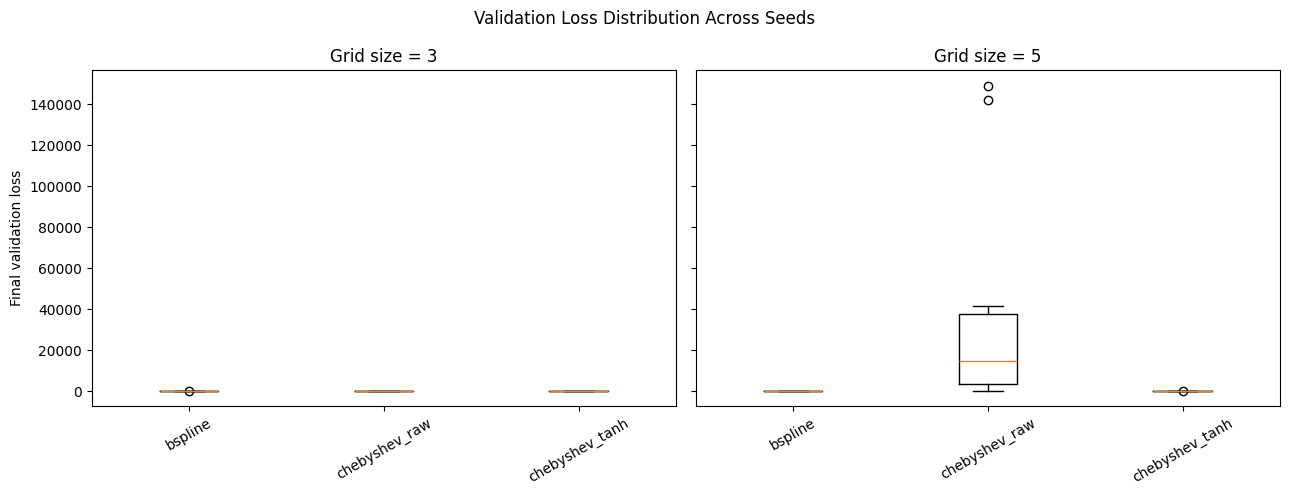

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, grid in zip(axes, sorted(df_primary['grid_size'].dropna().unique())):
    sub = df_primary[df_primary['grid_size'] == grid]
    groups = [g['final_val_loss'].dropna().values for _, g in sub.groupby('label')]
    labels = list(sub.groupby('label').groups.keys())
    ax.boxplot(groups, tick_labels=labels)
    ax.set_title(f'Grid size = {int(grid)}')
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Final validation loss')
fig.suptitle('Validation Loss Distribution Across Seeds')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig1_val_loss_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1155/4269177664.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)
/tmp/ipykernel_1155/4269177664.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)


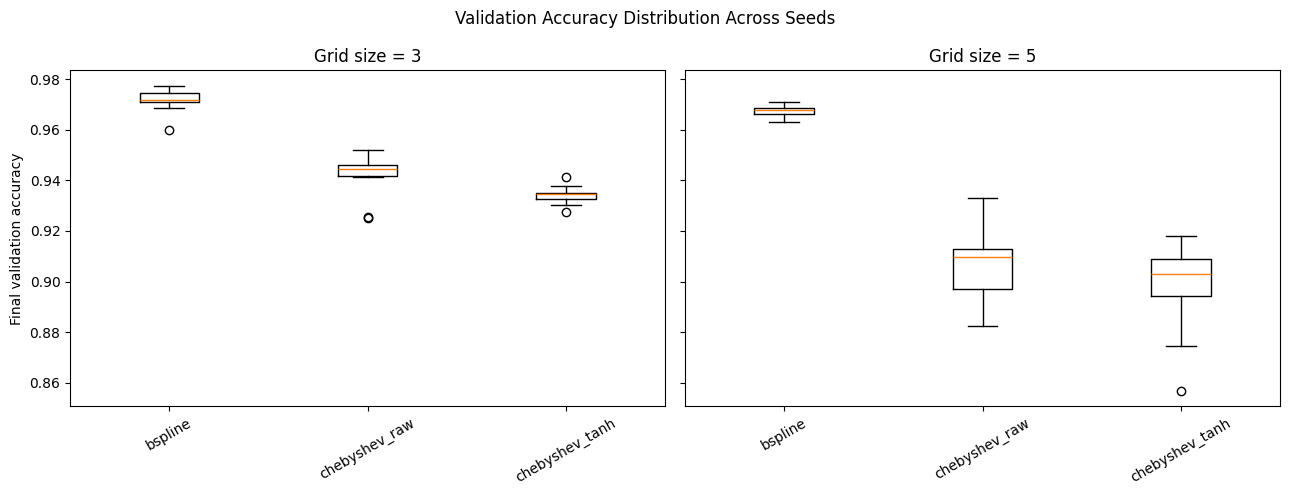

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, grid in zip(axes, sorted(df_primary['grid_size'].dropna().unique())):
    sub = df_primary[df_primary['grid_size'] == grid]
    groups = [g['final_val_acc'].dropna().values for _, g in sub.groupby('label')]
    labels = list(sub.groupby('label').groups.keys())
    ax.boxplot(groups, labels=labels)
    ax.set_title(f'Grid size = {int(grid)}')
    ax.tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Final validation accuracy')
fig.suptitle('Validation Accuracy Distribution Across Seeds')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig3_val_acc_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

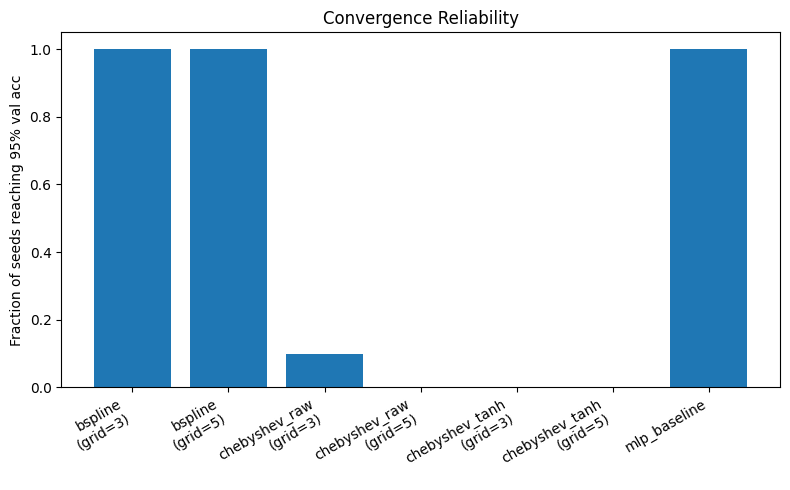

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
rel = df_primary.groupby(['label', 'grid_size'], dropna=False)['final_val_acc'].apply(lambda s: (s >= 0.95).mean())
rel = rel.reset_index()
rel['xlabel'] = rel.apply(lambda r: f"{r['label']}\n(grid={int(r['grid_size'])})" if pd.notna(r['grid_size']) else r['label'], axis=1)
ax.bar(rel['xlabel'], rel['final_val_acc'])
ax.set_ylabel('Fraction of seeds reaching 95% val acc')
ax.set_title('Convergence Reliability')
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig4_convergence_reliability.png'), dpi=150, bbox_inches='tight')
plt.show()

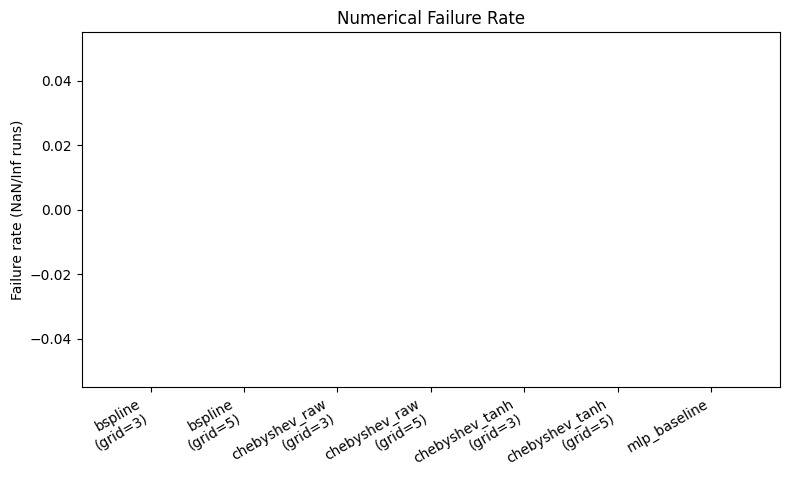

No failed runs recorded in the primary benchmark.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
fail = df_primary.groupby(['label', 'grid_size'], dropna=False)['failed'].mean().reset_index()
fail['xlabel'] = fail.apply(lambda r: f"{r['label']}\n(grid={int(r['grid_size'])})" if pd.notna(r['grid_size']) else r['label'], axis=1)
ax.bar(fail['xlabel'], fail['failed'], color='indianred')
ax.set_ylabel('Failure rate (NaN/Inf runs)')
ax.set_title('Numerical Failure Rate')
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig5_failure_rate.png'), dpi=150, bbox_inches='tight')
plt.show()

# also break down failure reasons, if any occurred
if df_primary['failed'].any():
    reason_counts = df_primary[df_primary['failed']]['fail_reason'].value_counts()
    print("Failure reasons observed:\n", reason_counts)
else:
    print("No failed runs recorded in the primary benchmark.")

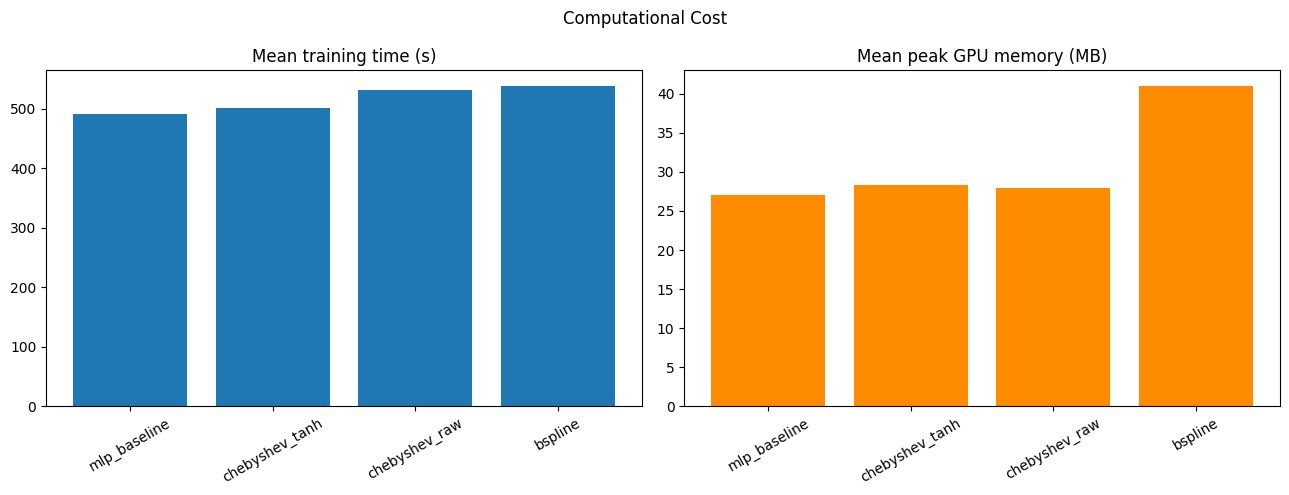

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
time_by = df_primary.groupby('label')['train_time_sec'].mean().sort_values()
mem_by = df_primary.groupby('label')['peak_gpu_mem_mb'].mean().reindex(time_by.index)

axes[0].bar(time_by.index, time_by.values)
axes[0].set_title('Mean training time (s)')
axes[1].bar(mem_by.index, mem_by.values, color='darkorange')
axes[1].set_title('Mean peak GPU memory (MB)')
for a in axes:
    a.tick_params(axis='x', rotation=30)
fig.suptitle('Computational Cost')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig6_computational_cost.png'), dpi=150, bbox_inches='tight')
plt.show()

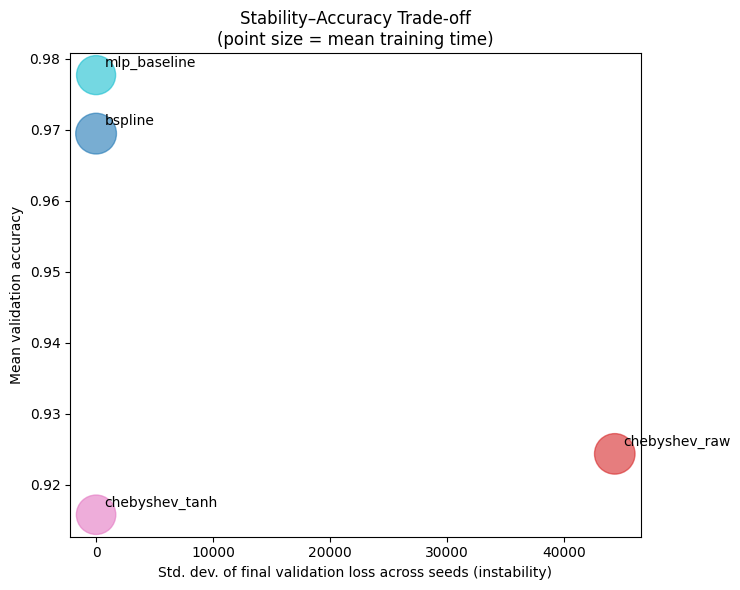

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
grp = df_primary.groupby('label').agg(
    std_loss=('final_val_loss', 'std'),
    mean_acc=('final_val_acc', 'mean'),
    cost=('train_time_sec', 'mean'),
).reset_index()

sizes = (grp['cost'] / grp['cost'].max()) * 800 + 60
scatter = ax.scatter(grp['std_loss'], grp['mean_acc'], s=sizes, alpha=0.6, c=range(len(grp)), cmap='tab10')
for _, row in grp.iterrows():
    ax.annotate(row['label'], (row['std_loss'], row['mean_acc']),
                textcoords="offset points", xytext=(6, 6))
ax.set_xlabel('Std. dev. of final validation loss across seeds (instability)')
ax.set_ylabel('Mean validation accuracy')
ax.set_title('Stability–Accuracy Trade-off\n(point size = mean training time)')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig7_stability_accuracy_tradeoff.png'), dpi=150, bbox_inches='tight')
plt.show()

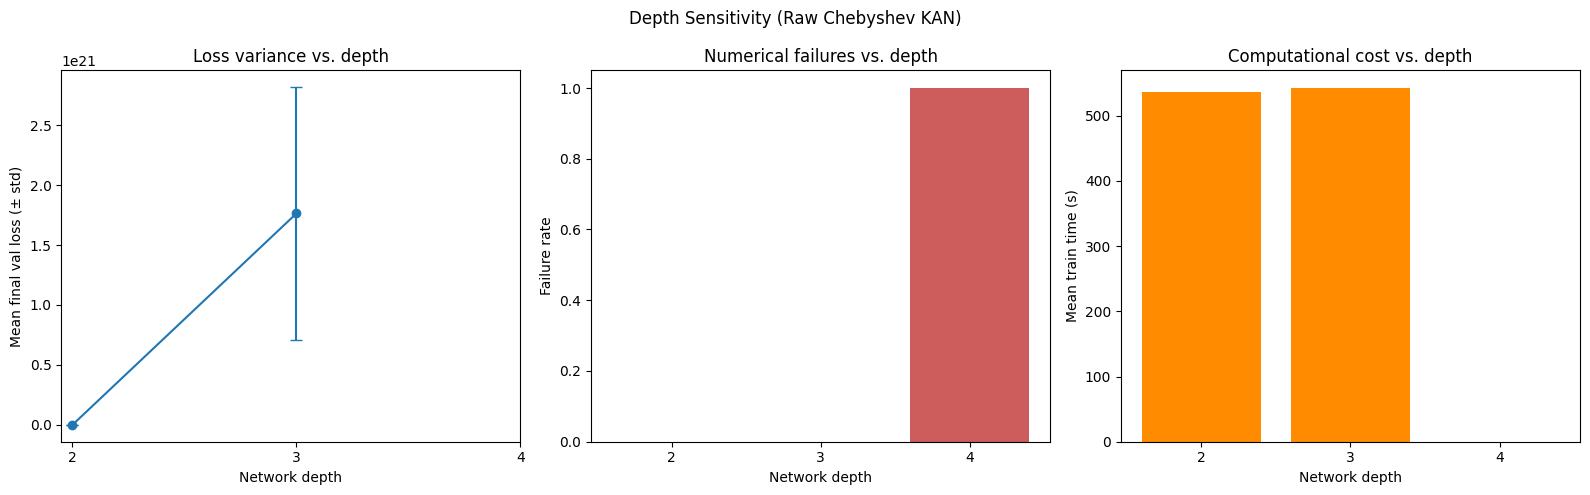

,depth,mean_val_loss,std_val_loss,failure_rate,mean_train_time
0,2,4.110635e+04,6.105901e+04,0.0,536.0861
1,3,1.763470e+21,1.052747e+21,0.0,542.5153
2,4,NaN,NaN,1.0,0.1346


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

depth_stats = df_depth.groupby('depth').agg(
    mean_val_loss=('final_val_loss', 'mean'),
    std_val_loss=('final_val_loss', 'std'),
    failure_rate=('failed', 'mean'),
    mean_train_time=('train_time_sec', 'mean'),
).reset_index().sort_values('depth')

axes[0].errorbar(depth_stats['depth'], depth_stats['mean_val_loss'], yerr=depth_stats['std_val_loss'],
                  marker='o', capsize=4)
axes[0].set_xlabel('Network depth'); axes[0].set_ylabel('Mean final val loss (± std)')
axes[0].set_title('Loss variance vs. depth')
axes[0].set_xticks(depth_stats['depth'])

axes[1].bar(depth_stats['depth'].astype(str), depth_stats['failure_rate'], color='indianred')
axes[1].set_xlabel('Network depth'); axes[1].set_ylabel('Failure rate')
axes[1].set_title('Numerical failures vs. depth')

axes[2].bar(depth_stats['depth'].astype(str), depth_stats['mean_train_time'], color='darkorange')
axes[2].set_xlabel('Network depth'); axes[2].set_ylabel('Mean train time (s)')
axes[2].set_title('Computational cost vs. depth')

fig.suptitle('Depth Sensitivity (Raw Chebyshev KAN)')
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig8_depth_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

table_depth = depth_stats.round(4)
table_depth.to_csv(os.path.join(TAB_DIR, 'table_depth_ablation.csv'), index=False)
table_depth

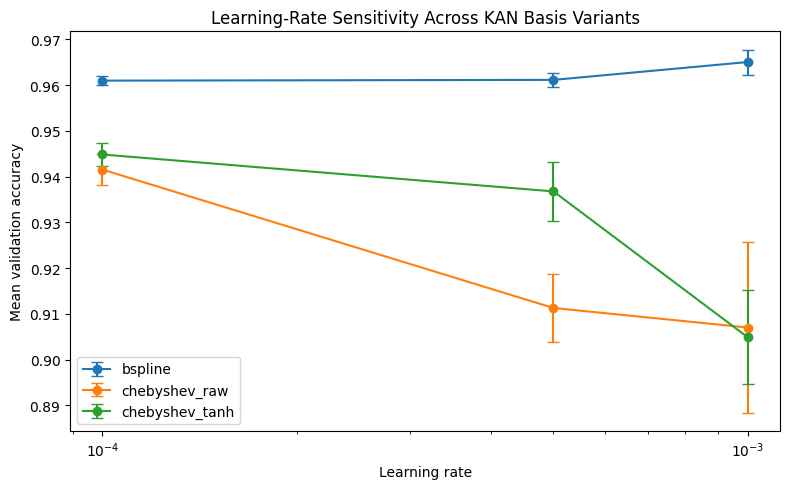

,label,lr,mean_val_acc,std_val_acc,failure_rate
0,bspline,0.0001,0.9610,0.0009,0.0
1,bspline,0.0005,0.9611,0.0016,0.0
2,bspline,0.0010,0.9650,0.0027,0.0
3,chebyshev_raw,0.0001,0.9415,0.0034,0.0
4,chebyshev_raw,0.0005,0.9113,0.0075,0.0
5,chebyshev_raw,0.0010,0.9070,0.0187,0.0
6,chebyshev_tanh,0.0001,0.9448,0.0025,0.0
7,chebyshev_tanh,0.0005,0.9368,0.0065,0.0
8,chebyshev_tanh,0.0010,0.9049,0.0102,0.0


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
lr_stats = df_lr.groupby(['label', 'lr']).agg(
    mean_val_acc=('final_val_acc', 'mean'),
    std_val_acc=('final_val_acc', 'std'),
    failure_rate=('failed', 'mean'),
).reset_index()

for name, sub in lr_stats.groupby('label'):
    sub = sub.sort_values('lr')
    ax.errorbar(sub['lr'], sub['mean_val_acc'], yerr=sub['std_val_acc'], marker='o', label=name, capsize=4)
ax.set_xscale('log')
ax.set_xlabel('Learning rate'); ax.set_ylabel('Mean validation accuracy')
ax.set_title('Learning-Rate Sensitivity Across KAN Basis Variants')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fig_lr_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

lr_table = lr_stats.round(4)
lr_table.to_csv(os.path.join(TAB_DIR, 'table_lr_sensitivity.csv'), index=False)
lr_table

In [ ]:
def summarize_regression(df, name):
    s = df.groupby('label').agg(
        n_runs=('test_metric', 'count'),
        mean_test_mse=('test_metric', 'mean'),
        std_test_mse=('test_metric', 'std'),
        failure_rate=('failed', 'mean'),
        mean_train_time=('train_time_sec', 'mean'),
    ).reset_index().round(5)
    s.to_csv(os.path.join(TAB_DIR, f'table_{name}.csv'), index=False)
    return s

table_func = summarize_regression(df_func, 'synthetic_function')
table_conc = summarize_regression(df_conc, 'concrete_regression')

print("Synthetic function approximation:")
display(table_func)
print("\nUCI Concrete regression:")
display(table_conc)

Synthetic function approximation:


,label,n_runs,mean_test_mse,std_test_mse,failure_rate,mean_train_time
0,bspline,0,NaN,NaN,0.0,6.85609
1,chebyshev_raw,0,NaN,NaN,0.0,4.37537
2,chebyshev_tanh,0,NaN,NaN,0.0,5.12760



UCI Concrete regression:


,label,n_runs,mean_test_mse,std_test_mse,failure_rate,mean_train_time
0,bspline,0,NaN,NaN,0.0,9.75517
1,chebyshev_raw,0,NaN,NaN,1.0,0.00238
2,chebyshev_tanh,0,NaN,NaN,0.0,6.42379


In [ ]:
def df_to_latex(df, caption, label, path, float_fmt="%.4f"):
    latex = df.to_latex(index=False, caption=caption, label=label, float_format=float_fmt, escape=True)
    with open(path, 'w') as f:
        f.write(latex)
    print("Saved:", path)
    return latex

df_to_latex(table1_display, "Primary benchmark: descriptive statistics across 10 seeds per configuration.",
            "tab:primary", os.path.join(TAB_DIR, 'table1_primary_benchmark.tex'))

df_to_latex(table_depth, "Depth sensitivity of raw Chebyshev KAN.",
            "tab:depth", os.path.join(TAB_DIR, 'table_depth_ablation.tex'))

df_to_latex(lr_table, "Learning-rate sensitivity across KAN basis variants.",
            "tab:lr", os.path.join(TAB_DIR, 'table_lr_sensitivity.tex'))

df_to_latex(table_func, "Synthetic function approximation: test MSE across seeds.",
            "tab:func", os.path.join(TAB_DIR, 'table_synthetic_function.tex'))

df_to_latex(table_conc, "UCI Concrete Compressive Strength regression: test MSE across seeds.",
            "tab:concrete", os.path.join(TAB_DIR, 'table_concrete.tex'))

print("\nAll figures saved to:", FIG_DIR)
print("All tables saved to:", TAB_DIR)

Saved: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/tables/table1_primary_benchmark.tex
Saved: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/tables/table_depth_ablation.tex
Saved: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/tables/table_lr_sensitivity.tex
Saved: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/tables/table_synthetic_function.tex
Saved: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/tables/table_concrete.tex

All figures saved to: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/figures
All tables saved to: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/tables


NameError: name 'FIG_DIR' is not defined

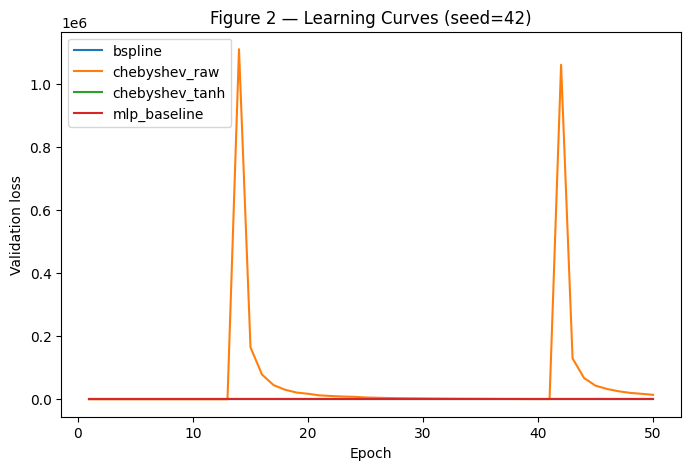

In [ ]:
def train_with_history(config, train_loader_fn, val_loader, task='classification', epochs=50):
    set_seed(config['seed'])
    model = build_model(config)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get('lr', 1e-3))
    criterion = nn.CrossEntropyLoss()
    train_loader = train_loader_fn(config['seed'])
    history = []
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            if torch.isnan(loss) or torch.isinf(loss):
                history.append(float('nan')); return history
            loss.backward(); optimizer.step()
        model.eval()
        total_loss, total = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                total_loss += criterion(out, yb).item() * xb.size(0); total += xb.size(0)
        history.append(total_loss / total)
    return history

# Redefine APPROACH_SPECS to make the cell independent and avoid NameError
APPROACH_SPECS = {
    'bspline': {'basis': 'bspline', 'stabilize': False},
    'chebyshev_raw': {'basis': 'chebyshev', 'stabilize': False},
    'chebyshev_tanh': {'basis': 'chebyshev', 'stabilize': True},
}

REP_SEED = 42
histories = {}
for name, spec in APPROACH_SPECS.items():
    cfg = {'model_type': 'kan', 'basis': spec['basis'], 'stabilize': spec['stabilize'],
           'grid_size': 5, 'degree': 5, 'layer_sizes': [784, 64, 10], 'seed': REP_SEED, 'lr': PRIMARY_LR}
    histories[name] = train_with_history(cfg, make_train_loader_fn, val_loader)
cfg_mlp = {'model_type': 'mlp', 'in_dim': 784, 'out_dim': 10, 'mlp_hidden': MLP_HIDDEN, 'seed': REP_SEED, 'lr': PRIMARY_LR}
histories['mlp_baseline'] = train_with_history(cfg_mlp, make_train_loader_fn, val_loader)

fig, ax = plt.subplots(figsize=(8, 5))
for name, h in histories.items():
    ax.plot(range(1, len(h) + 1), h, label=name)
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation loss')
ax.set_title(f'Figure 2 — Learning Curves (seed={REP_SEED})')
ax.legend()
fig.savefig(os.path.join(FIG_DIR, 'fig2_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Create a DataFrame from the training histories
epoch_indices = range(1, len(next(iter(histories.values()))) + 1)
df_history = pd.DataFrame(histories, index=epoch_indices)
df_history.index.name = 'Epoch'

# Display the table
pd.set_option('display.max_rows', 100)
display(df_history)

,bspline,chebyshev_raw,chebyshev_tanh,mlp_baseline
Epoch,,,,
1,0.236892,1.103180e+01,0.716476,0.196395
2,0.191210,4.103498e+00,0.482895,0.124576
3,0.166522,2.620097e+00,0.522696,0.112406
4,0.145342,1.924526e+00,0.509802,0.087522
5,0.148610,1.532816e+00,0.377503,0.084677
6,0.131320,1.294117e+00,0.400864,0.085069
7,0.149266,1.087479e+00,0.372115,0.084759
8,0.133923,9.597411e-01,0.340474,0.086946
9,0.142962,8.566858e-01,0.371369,0.090264


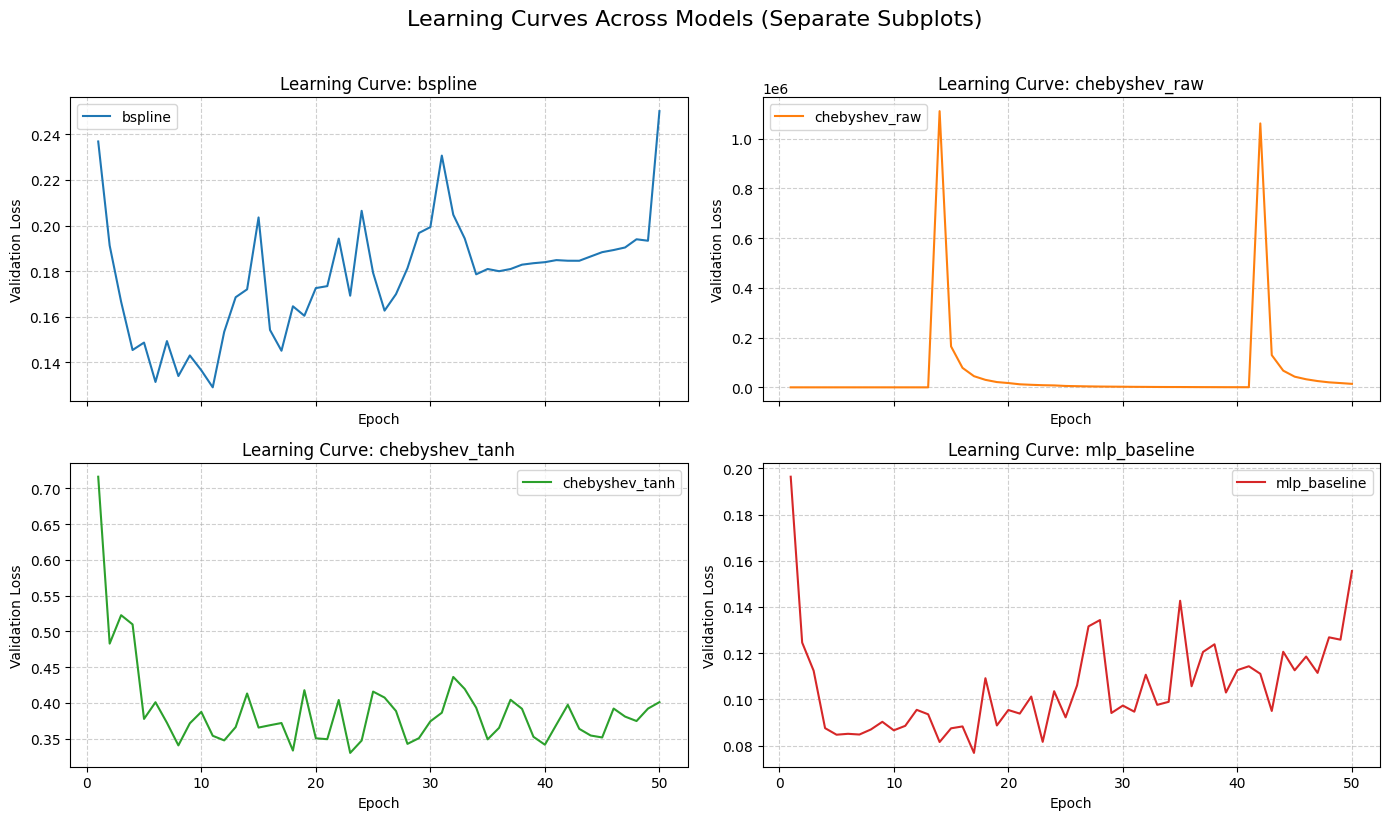

In [ ]:
import matplotlib.pyplot as plt
import math

# Set up separate grid plots for each model
num_models = len(histories)
cols = 2
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows), sharex=True)
axes = axes.flatten()

for i, (name, h) in enumerate(histories.items()):
    ax = axes[i]
    ax.plot(range(1, len(h) + 1), h, label=name, color=plt.cm.tab10(i))
    ax.set_title(f"Learning Curve: {name}")
    ax.set_ylabel("Validation Loss")
    ax.set_xlabel("Epoch")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

# Hide any unused subplots
for j in range(num_models, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Learning Curves Across Models (Separate Subplots)", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

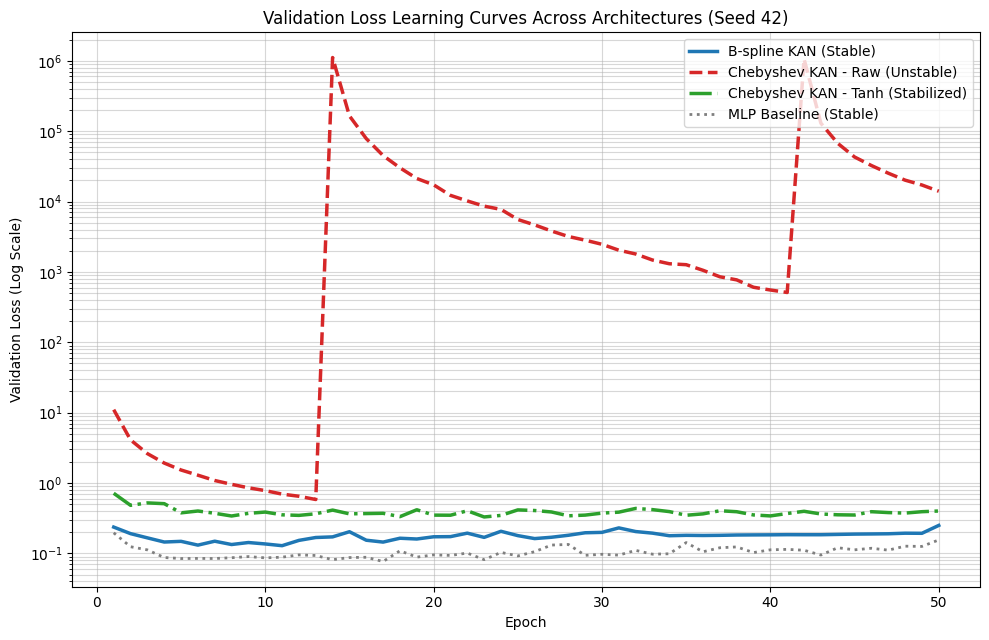

Saved comparative plot to: /content/drive/MyDrive/KAN_Stability_Study/paper_assets/figures/fig2_learning_curves_comparative.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Re-establish FIG_DIR in case of kernel restarts or state loss
PAPER_DIR = '/content/drive/MyDrive/KAN_Stability_Study/paper_assets'
FIG_DIR = os.path.join(PAPER_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

plt.figure(figsize=(10, 6.5))

# Plot each curve with distinct styling
plt.plot(range(1, len(histories['bspline']) + 1), histories['bspline'],
         label='B-spline KAN (Stable)', color='#1f77b4', linewidth=2.5, linestyle='-')

plt.plot(range(1, len(histories['chebyshev_raw']) + 1), histories['chebyshev_raw'],
         label='Chebyshev KAN - Raw (Unstable)', color='#d62728', linewidth=2.5, linestyle='--')

plt.plot(range(1, len(histories['chebyshev_tanh']) + 1), histories['chebyshev_tanh'],
         label='Chebyshev KAN - Tanh (Stabilized)', color='#2ca02c', linewidth=2.5, linestyle='-.')

plt.plot(range(1, len(histories['mlp_baseline']) + 1), histories['mlp_baseline'],
         label='MLP Baseline (Stable)', color='#7f7f7f', linewidth=2.0, linestyle=':')

# Configure labels, log scale due to Chebyshev Raw explosion
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (Log Scale)')
plt.title('Validation Loss Learning Curves Across Architectures (Seed 42)')

# Use normal legends as requested
plt.legend(loc='upper right')
plt.grid(True, which='both', alpha=0.5)

# Save the figure to paper assets
fig_path = os.path.join(FIG_DIR, 'fig2_learning_curves_comparative.png')
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("Saved comparative plot to:", fig_path)

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from scipy import stats

# ==========================================
# 1 & 2. GRADIENT & ACTIVATION STATISTICS HOOKS
# ==========================================

class StabilityDiagnosticsHook:
    def __init__(self):
        self.clear()

    def clear(self):
        self.activations = {}
        self.gradients = {}

    def get_activation_hook(self, name):
        def hook(model, input, output):
            act_data = output.detach().cpu()
            self.activations[name] = {
                'mean_magnitude': torch.mean(torch.abs(act_data)).item(),
                'max_magnitude': torch.max(torch.abs(act_data)).item(),
                'variance': torch.var(act_data).item()
            }
        return hook

    def get_gradient_hook(self, name):
        def hook(module, grad_input, grad_output):
            if grad_output[0] is not None:
                grad_data = grad_output[0].detach().cpu()
                self.gradients[name] = {
                    'mean_norm': torch.mean(torch.norm(grad_data, dim=-1)).item(),
                    'max_norm': torch.max(torch.norm(grad_data, dim=-1)).item(),
                    'variance': torch.var(grad_data).item()
                }
        return hook

# ==========================================
# 3. EXPLICIT INSTABILITY CLASSIFIER
# ==========================================

def classify_instability_event(val_losses, max_grad_norm=None, final_val_acc=None):
    """
    Classifies a run's training trajectory into stability classes.
    """
    if len(val_losses) == 0:
        return 'NaN/Inf'

    losses = np.array(val_losses)
    if np.any(np.isnan(losses)) or np.any(np.isinf(losses)):
        return 'NaN/Inf'

    if max_grad_norm is not None and (np.isnan(max_grad_norm) or np.isinf(max_grad_norm) or max_grad_norm > 1e4):
        return 'exploding gradient'

    # Check for explosion
    if losses[-1] > 10 * losses[0] or losses[-1] > 1e2:
        return 'exploding loss'

    # Complete divergence (extremely poor convergence on trivial classification task)
    if final_val_acc is not None and final_val_acc < 0.20:
        return 'complete divergence'

    # Oscillatory behavior (using sign changes of loss differences)
    if len(losses) >= 10:
        diffs = np.diff(losses[-10:])
        sign_changes = np.sum(diffs[:-1] * diffs[1:] < 0)
        if sign_changes >= 5:
            return 'oscillatory'

    return 'stable'

# ==========================================
# 4. BETTER PARAMETER MATCHING (Dynamic MLP Builder)
# ==========================================

def build_mlp_for_target_params(in_features, out_features, target_params):
    """
    Dynamically resolves the hidden size of a single-hidden-layer MLP
    to precisely match target parameters as close as possible.
    Formula: in_features * h + h + h * out_features + out_features = target_params
    h * (in_features + 1 + out_features) + out_features = target_params
    """
    denominator = in_features + 1 + out_features
    h = int(round((target_params - out_features) / denominator))
    h = max(1, h)

    model = nn.Sequential(
        nn.Linear(in_features, h),
        nn.ReLU(),
        nn.Linear(h, out_features)
    )
    actual_params = sum(p.numel() for p in model.parameters())
    return model, h, actual_params

# ==========================================
# 5. STATISTICAL TESTING & EFFECT SIZE
# ==========================================

def run_statistical_comparison(group_a, group_b, label_a="KAN", label_b="MLP"):
    """
    Performs Welch's t-test, computes 95% Confidence Intervals, and calculates Cohen's d.
    """
    a = np.array(group_a)
    b = np.array(group_b)

    mean_a, mean_b = np.mean(a), np.mean(b)
    std_a, std_b = np.std(a, ddof=1), np.std(b, ddof=1)
    n_a, n_b = len(a), len(b)

    # Welch's t-test
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)

    # Cohen's d effect size
    pooled_std = np.sqrt(((n_a - 1) * (std_a ** 2) + (n_b - 1) * (std_b ** 2)) / (n_a + n_b - 2))
    cohens_d = (mean_a - mean_b) / pooled_std if pooled_std != 0 else 0

    # Confidence Intervals (95% CI of the mean for each)
    ci_a = stats.t.interval(0.95, n_a - 1, loc=mean_a, scale=stats.sem(a))
    ci_b = stats.t.interval(0.95, n_b - 1, loc=mean_b, scale=stats.sem(b))

    return {
        f'{label_a}_mean': mean_a,
        f'{label_a}_95_ci': ci_a,
        f'{label_b}_mean': mean_b,
        f'{label_b}_95_ci': ci_b,
        't_statistic': t_stat,
        'p_value': p_val,
        'cohens_d': cohens_d
    }

# Demonstrate Parameter Matching Utility
target = 457344
_, h, actual = build_mlp_for_target_params(784, 10, target)
print(f"[Dynamic Match] Target: {target} -> Resolved MLP Hidden: {h} (Actual: {actual}, Delta: {actual - target})")


[Dynamic Match] Target: 457344 -> Resolved MLP Hidden: 575 (Actual: 457135, Delta: -209)


In [ ]:
import os
import pandas as pd

# Ensure path variable is defined
COMBINED_DIR = '/content/drive/MyDrive/KAN_Stability_Study/combined_results'

# Load primary results
df_primary = pd.read_csv(os.path.join(COMBINED_DIR, 'primary_results_ALL.csv'))

# Filter groups to compare
bspline_5_acc = df_primary[(df_primary['config_name'] == 'bspline') & (df_primary['grid_size'] == 5)]['final_val_acc'].dropna().values
mlp_acc = df_primary[df_primary['config_name'] == 'mlp_baseline']['final_val_acc'].dropna().values

# Run statistical testing
stats_results = run_statistical_comparison(bspline_5_acc, mlp_acc, label_a="BSpline_KAN_G5", label_b="MLP_Baseline")

# Display Results nicely
print("=== STATISTICAL COMPARISON REPORT ===")
for key, val in stats_results.items():
    if '95_ci' in key:
        print(f"{key:25s}: ({val[0]:.6f}, {val[1]:.6f})")
    else:
        print(f"{key:25s}: {val}")


=== STATISTICAL COMPARISON REPORT ===
BSpline_KAN_G5_mean      : 0.9673499999999999
BSpline_KAN_G5_95_ci     : (0.965566, 0.969134)
MLP_Baseline_mean        : 0.9776666666666666
MLP_Baseline_95_ci       : (0.974948, 0.980385)
t_statistic              : -7.176948940569026
p_value                  : 2.6071527879152866e-06
cohens_d                 : -3.2096291404314887


In [ ]:
import time
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import random
import math

# Re-define core setup helpers locally to ensure a self-contained runtime
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def build_model(config):
    if config['model_type'] == 'mlp':
        return nn.Sequential(
            nn.Linear(config['in_dim'], config['mlp_hidden']),
            nn.ReLU(),
            nn.Linear(config['mlp_hidden'], config['out_dim']),
        ).to(DEVICE)
    raise ValueError("Unsupported model type in temp tester.")

# Self-contained loader generation for MNIST
def get_mnist_loaders_temp(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.view(-1) * 2 - 1),
    ])
    train_full = torchvision.datasets.MNIST(root='/content/drive/MyDrive/KAN_Stability_Study/data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.MNIST(root='/content/drive/MyDrive/KAN_Stability_Study/data', train=False, download=True, transform=transform)

    n_val = int(len(train_full) * 0.1)
    n_train = len(train_full) - n_val
    gen = torch.Generator().manual_seed(0)
    train_set, val_set = random_split(train_full, [n_train, n_val], generator=gen)

    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_set, val_loader

def make_train_loader_temp(train_set, seed, batch_size=128):
    g = torch.Generator(); g.manual_seed(seed)
    return DataLoader(train_set, batch_size=batch_size, shuffle=True, generator=g, num_workers=2)

# Initialize data loaders
train_set_temp, val_loader_temp = get_mnist_loaders_temp()
make_train_loader_fn_temp = lambda seed: make_train_loader_temp(train_set_temp, seed)

class EpochTelemetryTracker:
    def __init__(self, model, epsilon=1e-8):
        self.model = model
        self.epsilon = epsilon
        self.epoch_records = []
        self.activation_magnitudes = []
        self.max_activations = []
        self.hooks = []
        self._register_activation_hooks()

    def _register_activation_hooks(self):
        def hook_fn(module, input, output):
            act = output.detach().cpu()
            self.activation_magnitudes.append(torch.abs(act).mean().item())
            self.max_activations.append(torch.abs(act).max().item())

        for layer in self.model.modules():
            if isinstance(layer, nn.Linear):
                self.hooks.append(layer.register_forward_hook(hook_fn))

    def clear_hooks(self):
        for hook in self.hooks:
            hook.remove()
        self.hooks = []

    def record_epoch(self, epoch, train_loss, val_loss, val_acc, elapsed_time):
        # 1. Parameter metrics
        param_norms = [torch.norm(p.data).item() for p in self.model.parameters() if p.requires_grad]
        global_param_norm = np.linalg.norm(param_norms) if param_norms else 0.0

        # 2. Gradient metrics
        grad_norms = [torch.norm(p.grad).item() for p in self.model.parameters() if p.requires_grad and p.grad is not None]
        global_grad_norm = np.linalg.norm(grad_norms) if grad_norms else 0.0

        grad_maxs = [torch.max(torch.abs(p.grad)).item() for p in self.model.parameters() if p.requires_grad and p.grad is not None]
        max_param_grad = max(grad_maxs) if grad_maxs else 0.0

        grad_all = [p.grad.cpu().numpy().flatten() for p in self.model.parameters() if p.requires_grad and p.grad is not None]
        grad_variance = np.var(np.concatenate(grad_all)) if grad_all else 0.0

        # 3. Gradient-to-parameter ratio (R_t)
        r_t = global_grad_norm / (global_param_norm + self.epsilon)

        # 4. Activation statistics from hooks collected during the epoch
        mean_abs_act = np.mean(self.activation_magnitudes) if self.activation_magnitudes else 0.0
        max_act = np.max(self.max_activations) if self.max_activations else 0.0
        self.activation_magnitudes.clear()
        self.max_activations.clear()

        # 5. Peak memory
        peak_mem = torch.cuda.max_memory_allocated() / (1024 ** 2) if torch.cuda.is_available() else 0.0

        # 6. Stability Flags
        has_nan_inf = np.isnan(train_loss) or np.isinf(train_loss) or np.isnan(val_loss) or np.isinf(val_loss) or np.isnan(global_grad_norm) or np.isinf(global_grad_norm)
        exploding_grad = (global_grad_norm > 1e4)
        exploding_loss = (epoch > 1 and val_loss > 10.0)

        oscillation = False
        if len(self.epoch_records) >= 3:
            recent_losses = [r['validation_loss'] for r in self.epoch_records[-3:]] + [val_loss]
            diffs = np.diff(recent_losses)
            oscillation = bool(diffs[0] * diffs[1] < 0 and diffs[1] * diffs[2] < 0)

        self.epoch_records.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'validation_loss': val_loss,
            'accuracy': val_acc,
            'global_gradient_L2_norm': global_grad_norm,
            'maximum_parameter_gradient': max_param_grad,
            'gradient_variance': grad_variance,
            'mean_absolute_activation': mean_abs_act,
            'maximum_activation': max_act,
            'parameter_L2_norm': global_param_norm,
            'gradient_to_parameter_ratio_Rt': r_t,
            'nan_inf': has_nan_inf,
            'exploding_gradient': exploding_grad,
            'exploding_loss': exploding_loss,
            'oscillation': oscillation,
            'training_time_sec': elapsed_time,
            'peak_gpu_mem_mb': peak_mem
        })

def run_instrumented_training(config, train_loader_fn, val_loader, epochs=5):
    set_seed(config['seed'])
    model = build_model(config)
    tracker = EpochTelemetryTracker(model)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.get('lr', 1e-3))
    criterion = nn.CrossEntropyLoss()
    train_loader = train_loader_fn(config['seed'])

    print(f"Starting instrumented runs for: {config['config_name']}")
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train()
        running_train_loss = 0.0
        total_samples = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * xb.size(0)
            total_samples += xb.size(0)

        epoch_time = time.time() - t0
        train_loss = running_train_loss / total_samples

        # Validation phase
        model.eval()
        total_val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                loss = criterion(out, yb)
                total_val_loss += loss.item() * xb.size(0)
                correct += (out.argmax(1) == yb).sum().item()
                total += xb.size(0)

        val_loss = total_val_loss / total
        val_acc = correct / total

        # Record epoch metrics
        tracker.record_epoch(epoch, train_loss, val_loss, val_acc, epoch_time)
        print(f"Epoch {epoch:02d} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | R_t Ratio: {tracker.epoch_records[-1]['gradient_to_parameter_ratio_Rt']:.6f}")

    tracker.clear_hooks()
    return pd.DataFrame(tracker.epoch_records)

# Quick execution test with our matched MLP configuration
test_config = {
    'model_type': 'mlp',
    'config_name': 'mlp_test_telemetry',
    'in_dim': 784,
    'out_dim': 10,
    'mlp_hidden': h, # Resolved from active kernel state
    'seed': 42,
    'lr': 1e-3
}

df_telemetry = run_instrumented_training(test_config, make_train_loader_fn_temp, val_loader_temp, epochs=3)
display(df_telemetry.head())


Starting instrumented runs for: mlp_test_telemetry
Epoch 01 | Val Loss: 0.1964 | Val Acc: 0.9432 | R_t Ratio: 0.060227
Epoch 02 | Val Loss: 0.1246 | Val Acc: 0.9630 | R_t Ratio: 0.030354
Epoch 03 | Val Loss: 0.1124 | Val Acc: 0.9668 | R_t Ratio: 0.025881


,epoch,train_loss,validation_loss,accuracy,global_gradient_L2_norm,maximum_parameter_gradient,gradient_variance,mean_absolute_activation,maximum_activation,parameter_L2_norm,gradient_to_parameter_ratio_Rt,nan_inf,exploding_gradient,exploding_loss,oscillation,training_time_sec,peak_gpu_mem_mb
0,1,0.365601,0.196395,0.943167,1.083006,0.102614,2.565757e-06,2.478804,18.843737,17.982106,0.060227,False,False,False,False,8.911348,26.672852
1,2,0.164690,0.124576,0.963000,0.627951,0.080989,8.625944e-07,2.927130,23.645193,20.687512,0.030354,False,False,False,False,8.740044,26.672852
2,3,0.116687,0.112406,0.966833,0.594989,0.083612,7.733908e-07,3.327572,31.380470,22.989458,0.025881,False,False,False,False,7.192847,26.672852
